Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Estruturando os dados para dar foco aos Produtos...

Novas features baseadas no foco do produto:
 Index(['Estabelecimentos_Banana',
       'Estabelecimentos_Mandioca (aipim, macaxeira)', 'Producao_Banana',
       'Producao_Mandioca (aipim, macaxeira)'],
      dtype='object', name='Produto da Lavoura')
Formato da matriz de features: (1176, 4)
Variância explicada acumulada pelo PCA: 99.24%


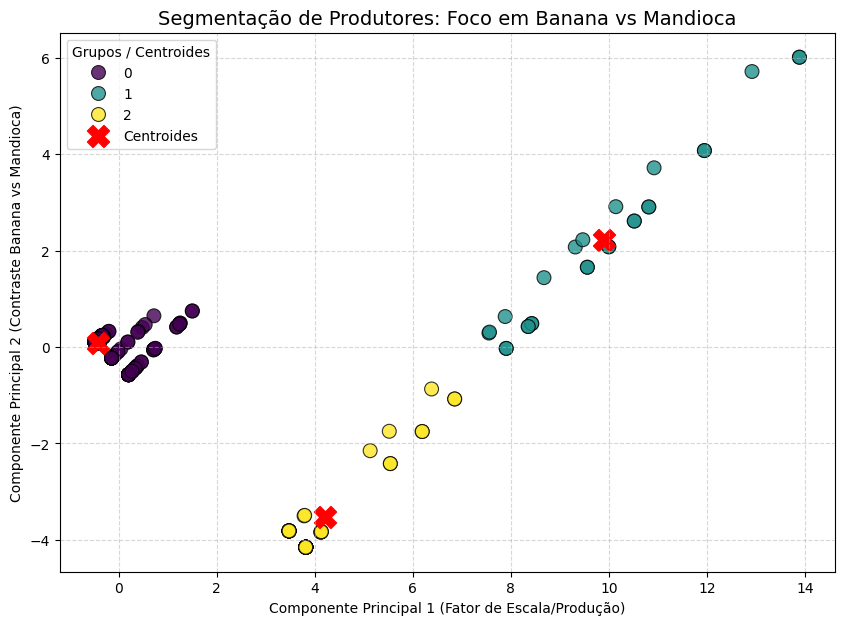


--- Métricas de Avaliação ---
Silhouette Score: 0.9571
Davies-Bouldin Score: 0.3265

=== CARACTERÍSTICAS DOS GRUPOS ENCONTRADOS (Médias) ===
Produto da Lavoura  Estabelecimentos_Banana  \
Cluster                                       
0                                      0.38   
1                                    102.67   
2                                      9.07   

Produto da Lavoura  Estabelecimentos_Mandioca (aipim, macaxeira)  \
Cluster                                                            
0                                                           0.20   
1                                                          44.59   
2                                                           3.36   

Produto da Lavoura  Producao_Banana  Producao_Mandioca (aipim, macaxeira)  
Cluster                                                                    
0                              0.33                                  4.11  
1                             29.00                  

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from warnings import filterwarnings

filterwarnings("ignore")

# ==========================================
# 2. CARREGAMENTO E REESTRUTURAÇÃO (PIVOT)
# ==========================================
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/AprendizadoMaquina/censo_2017_consolidado_final.csv')

# Tratar valores convertendo para numérico
data['Valor_estrutura'] = pd.to_numeric(data['Valor_estrutura'], errors='coerce').fillna(0)
data['Valor_producao'] = pd.to_numeric(data['Valor_producao'], errors='coerce').fillna(0)

print("Estruturando os dados para dar foco aos Produtos...")

# Criando DataFrames pivotados para separar as métricas por tipo de produto
df_pivot_est = data.pivot_table(
    index=['Tipologia', 'Sexo do produtor', 'Classe de idade do produtor', 'Condição do produtor em relação às terras'],
    columns='Produto da Lavoura',
    values='Valor_estrutura',
    aggfunc='sum'
).fillna(0).add_prefix('Estabelecimentos_')

df_pivot_prod = data.pivot_table(
    index=['Tipologia', 'Sexo do produtor', 'Classe de idade do produtor', 'Condição do produtor em relação às terras'],
    columns='Produto da Lavoura',
    values='Valor_producao',
    aggfunc='sum'
).fillna(0).add_prefix('Producao_')

# Juntando as visões de estrutura e produção focadas no produto
df_foco_produto = df_pivot_est.join(df_pivot_prod).reset_index()

# Definindo as colunas numéricas geradas que vão alimentar o modelo
features_produto = [
    'Estabelecimentos_Banana',
    'Estabelecimentos_Mandioca (aipim, macaxeira)',
    'Producao_Banana',
    'Producao_Mandioca (aipim, macaxeira)'
]

df_features = df_foco_produto[features_produto]
print("\nNovas features baseadas no foco do produto:\n", df_features.columns)
print(f"Formato da matriz de features: {df_features.shape}")

# ==========================================
# 3. PRÉ-PROCESSAMENTO (ESCALONAMENTO)
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

# ==========================================
# 4. APLICAÇÃO DO PCA (REDUÇÃO DE DIMENSÃO)
# ==========================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=X_pca, columns=['Componente_Principal_1', 'Componente_Principal_2'])
print(f"Variância explicada acumulada pelo PCA: {sum(pca.explained_variance_ratio_):.2%}")

# ==========================================
# 5. EXECUÇÃO DO K-MEANS NOS DADOS DO PCA
# ==========================================
# 3 clusters tendem a isolar bem: Especialistas em Banana, Especialistas em Mandioca e Diversificados/Baixa prod.
n_clusters_ideal = 3

kmeans = KMeans(n_clusters=n_clusters_ideal, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(df_pca)

df_pca['Cluster'] = cluster_labels
df_foco_produto['Cluster'] = cluster_labels

# ==========================================
# 6. VISUALIZAÇÃO GRÁFICA DOS CLUSTERS (2D)
# ==========================================
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Componente_Principal_1',
    y='Componente_Principal_2',
    hue='Cluster',
    data=df_pca,
    palette='viridis',
    alpha=0.8,
    edgecolor='k',
    s=100
)

centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], s=250, c='red', marker='X', label='Centroides')

plt.title('Segmentação de Produtores: Foco em Banana vs Mandioca', fontsize=14)
plt.xlabel('Componente Principal 1 (Fator de Escala/Produção)')
plt.ylabel('Componente Principal 2 (Contraste Banana vs Mandioca)')
plt.legend(title='Grupos / Centroides')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==========================================
# 7. ANÁLISE DOS RESULTADOS E PERFIS
# ==========================================
print("\n--- Métricas de Avaliação ---")
print(f"Silhouette Score: {silhouette_score(df_pca.drop(columns=['Cluster']), cluster_labels):.4f}")
print(f"Davies-Bouldin Score: {davies_bouldin_score(df_pca.drop(columns=['Cluster']), cluster_labels):.4f}")

print("\n=== CARACTERÍSTICAS DOS GRUPOS ENCONTRADOS (Médias) ===")
resumo = df_foco_produto.groupby('Cluster')[features_produto].mean()
print(resumo.round(2))

print("\n=== PERFIL DOS ESTABELECIMENTOS MAIS COMUNS POR CLUSTER ===")
for cluster in sorted(df_foco_produto['Cluster'].unique()):
    print(f"\n--- Perfil Predominante no Cluster {cluster} ---")
    df_c = df_foco_produto[df_foco_produto['Cluster'] == cluster]
    print("Tipologia:", df_c['Tipologia'].mode()[0])
    print("Condição da Terra:", df_c['Condição do produtor em relação às terras'].mode()[0])
    print("Sexo do Produtor:", df_c['Sexo do produtor'].mode()[0])

In [ ]:
Antes de olhar para a agricultura, os indicadores estatísticos mostram que o modelo ficou excelente:

Variância Explicada pelo PCA (99,24%): Significa que ao reduzir o problema para 2 componentes principais, praticamente nenhuma informação relevante foi perdida. Os dados de Cruz das Almas são muito lineares em relação à escala.

Silhouette Score (0,9571): É um valor altíssimo (o máximo é 1.0). Indica que os clusters estão extremamente bem separados e que não há sobreposição ou confusão entre os grupos.

Davies-Bouldin Score (0,3265): Sendo um valor baixo (quanto mais próximo de 0, melhor), ele confirma que a distância dentro de cada grupo é pequena e a distância entre os grupos é grande.

2. Radiografia dos Clusters (Os Perfis Agrícolas)
📌 Cluster 0: A "Franja" ou Pequenos Produtores de Subsistência
Métricas Médias: Quase zero em estabelecimentos e produção média muito baixa (0.33 para banana e 4.11 para mandioca).

Perfil Predominante: Agricultura Familiar - Pronaf V | Arrendatários | Homens.

Análise: Este é o maior grupo em número de linhas (visto o formato da matriz). Representa produtores familiares com terras arrendadas (não são donos) pertencentes ao Pronaf V (uma linha de crédito para produtores com renda um pouco maior ou projetos específicos, mas que aqui aparecem em registros pulverizados e de baixa escala produtiva individual). É a base da pirâmide que planta para consumo próprio ou comércio local muito restrito.

📌 Cluster 1: Os Grandes Produtores / Polos de Produção da Região
Métricas Médias: Altíssima concentração. Média de 102.67 estabelecimentos para Banana e 44.59 para Mandioca. A produção de mandioca dispara para 402.00 (provavelmente toneladas ou áreas colhidas massivas) e a de banana para 29.00.

Perfil Predominante: Agricultura Familiar - Pronaf B | Proprietários | Homens.

Análise: Aqui estão os donos de terra que movimentam a economia agrícola de Cruz das Almas. O Pronaf B é voltado para micro-produtores de baixa renda (historicamente conhecidos como agroamigos/com renda bruta familiar anual menor), mas o dado nos mostra algo fascinante: quando somados e consolidados em suas propriedades, eles dominam o volume produtivo de mandioca e banana na região. É o cooperativismo ou a força coletiva da agricultura familiar proprietária.

📌 Cluster 2: O Grupo Institucional ou "Sem Gênero Definido"
Métricas Médias: Escala intermediária de estabelecimentos (9.07 para banana, 3.36 para mandioca), mas replicando os tetos de produção (29.00 e 402.00).

Perfil Predominante: Agricultura Familiar - Pronaf B | Proprietários | Não se aplica (Sexo).

Análise: O detalhe do sexo como "Não se aplica" indica que este cluster capturou registros associados a Pessoas Jurídicas, Cooperativas, Associações ou condomínios agrícolas formados por produtores do Pronaf B. Eles possuem uma escala de estabelecimentos organizada e centralizam uma fatia pesada da produção regional.

3. Principais Insights para Cruz das Almas (BA)
A Mandioca é a Rainha do Volume: Em ambos os clusters produtivos (1 e 2), o volume de mandioca (402.00) é esmagadoramente superior ao da banana (29.00). Isso valida a forte identidade histórica do município com a cultura da mandioca (famosa pelas casas de farinha da região).

A Força da Propriedade da Terra: O sucesso e a escala da produção (Clusters 1 e 2) estão diretamente atrelados à condição de Proprietário(a). Quem é arrendatário (Cluster 0) acaba ficando retido na baixíssima escala.

Agricultura Familiar comanda o cenário: Toda a segmentação relevante foi dominada pela tipologia de Agricultura Familiar (seja Pronaf B ou V). O agronegócio de grande porte/patronal não sobressaiu no topo desses perfis de banana e mandioca, mostrando que o município depende crucialmente do pequeno produtor organizado para abastecer essas cadeias.